# NASDAQ Intraday Trading Strategy

This notebook builds and backtests a volatility-based intraday trading strategy using NASDAQ stock data (AAPL).

In [11]:
# Step 1: Import libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import seaborn as sns
plt.style.use('seaborn-v0_8')  # Use the updated style name
# plt.style.use('seaborn')

In [12]:
# Step 2: Download 5-minute intraday data for AAPL
ticker = 'AAPL'
data = yf.download(ticker, period='5d', interval='5m')
data.dropna(inplace=True)
data.head()

/tmp/ipython-input-12-467046786.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period='5d', interval='5m')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Datetime,,,,,
2025-07-11 13:30:00+00:00,210.720001,211.029907,209.880005,210.565002,2555952
2025-07-11 13:35:00+00:00,210.375000,210.869995,209.990005,210.690002,817196
2025-07-11 13:40:00+00:00,210.190002,210.389999,209.860001,210.375000,698002
2025-07-11 13:45:00+00:00,210.570007,210.669998,209.865005,210.179993,696214
2025-07-11 13:50:00+00:00,210.680206,210.796295,210.429993,210.559998,457985


In [13]:
# Step 3: Add VWAP and Z-score (volatility) filters
# Flatten column names if they're MultiIndex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

# Now proceed with the calculations
data['VWAP'] = (data['Close'] * data['Volume']).cumsum() / data['Volume'].cumsum()
data['Rolling_Mean'] = data['Close'].rolling(window=20).mean()
data['Rolling_Std'] = data['Close'].rolling(window=20).std()

# Avoid division by zero and ensure we're working with Series
data['Zscore'] = (data['Close'] - data['Rolling_Mean']) / data['Rolling_Std'].replace(0, np.nan)

In [14]:
# Step 4: Generate trading signals
data['Signal'] = 0
data.loc[(data['Close'] < data['VWAP']) & (data['Zscore'] < -1), 'Signal'] = 1  # Buy
data.loc[(data['Close'] > data['VWAP']) & (data['Zscore'] > 1), 'Signal'] = -1 # Sell
data['Position'] = data['Signal'].shift().fillna(0)

Text(0.5, 1.0, 'Cumulative Returns')

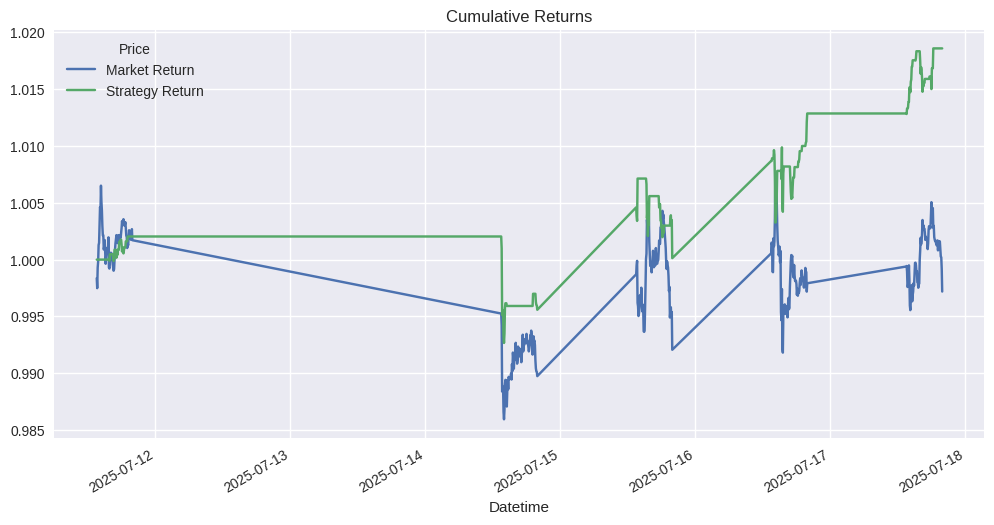

In [15]:
# Step 5: Simulate returns
data['Market Return'] = data['Close'].pct_change()
data['Strategy Return'] = data['Position'] * data['Market Return']
data[['Market Return', 'Strategy Return']].cumsum().apply(np.exp).plot(figsize=(12, 6))
plt.title('Cumulative Returns')

In [16]:
# Step 6: Performance metrics
sharpe = np.sqrt(252 * 78) * data['Strategy Return'].mean() / data['Strategy Return'].std()
total_profit = (data['Strategy Return'].cumsum().apply(np.exp).iloc[-1] - 1) * 100000
win_rate = (data['Strategy Return'] > 0).mean()
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Total Profit on $100000: ${total_profit:.2f}")
print(f"Win Rate: {win_rate*100:.2f}%")

Sharpe Ratio: 6.86
Total Profit on $100000: $1859.23
Win Rate: 17.69%
